# Umfassende Evaluation auf dem MERLIN CEFR-Benchmark (Boyd et al., 2014)
#### Empirischer Benchmark aller Regressoren, Klassifikatoren und traditionellen Lesbarkeitsmetriken auf 1.033 deutschen Volltexten (Dokumentebene) mit offiziellen CEFR-Niveaus (A1 bis C1)

---

## 1. Überblick & Fragestellung

Das **MERLIN-Korpus** (Boyd et al., 2014; Wisniewski et al., 2013) umfasst **1.033 authentische, vollständige deutsche Texte** (Aufsätze und Briefe aus standardisierten Sprachprüfungen wie telc und TestDaF), die von Sprachexperten offiziell nach dem Gemeinsamen Europäischen Referenzrahmen (**CEFR: A1, A2, B1, B2, C1, C2**) eingestuft wurden.

Im Gegensatz zu isolierten Einzelsätzen (wie in *TextComplexityDE*) ermöglicht MERLIN die Evaluation auf **echter Dokument- und Absatzebene** (durchschnittlich 120 Wörter bzw. 150–250 Tokens).

In diesem Notebook untersuchen wir:
1. **Regressoren:** Wie gut bilden die **BiLSTM MixUp-Regressoren (256, 512, 1024 Tokens)** die 5 realen CEFR-Schwierigkeitsstufen auf Dokumentebene ab?
2. **Klassifikatoren:** Zeigt die kontinuierliche Wahrscheinlichkeit $P(\text{LS})$ des Satz- bzw. der Artikel-Klassifikatoren eine saubere Monotonie über die CEFR-Niveaus ($A1 > A2 > B1 > B2 > C1$)?
3. **Vergleich mit traditionellen Formeln:** Übertreffen die neuronalen Modelle klassische Maße wie Flesch Reading Ease, Wiener Sachtextformel und LIX auf ganzen Texten?


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import mean_squared_error, mean_absolute_error

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, "data")) and os.path.exists(os.path.join(p, "results")):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser("~/Documents/Master Thesis"))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Arbeitsverzeichnis:", os.getcwd())

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 150
})


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. MERLIN Benchmark-Daten & Modell-Vorhersagen laden

Einlesen der vorberechneten Modellvorhersagen auf den 1.033 MERLIN-Dokumenten.

In [2]:
csv_path_all = "results/evaluation/merlin_all_models_eval.csv"
csv_path_texts = "data/analysis/merlin/merlin_texts.csv"

if os.path.exists(csv_path_all):
    df_merlin = pd.read_csv(csv_path_all)
    print(f"-> Detail-Vorhersagen geladen ({len(df_merlin)} Dokumente): {csv_path_all}")
elif os.path.exists(csv_path_texts):
    df_merlin = pd.read_csv(csv_path_texts)
    print(f"-> Rohe MERLIN-Texte geladen ({len(df_merlin)} Dokumente): {csv_path_texts}")
else:
    raise FileNotFoundError("Weder merlin_all_models_eval.csv noch merlin_texts.csv gefunden!")

cefr_order = {"A1": 1, "A2": 2, "B1": 3, "B2": 4, "C1": 5, "C2": 6}
if "cefr_num" not in df_merlin.columns and "cefr_level" in df_merlin.columns:
    df_merlin["cefr_num"] = df_merlin["cefr_level"].map(cefr_order)

if "cefr_simplicity" not in df_merlin.columns and "cefr_num" in df_merlin.columns:
    df_merlin["cefr_simplicity"] = 1.0 - ((df_merlin["cefr_num"] - 1.0) / 5.0)

y_simp = df_merlin["cefr_simplicity"].values
y_comp = df_merlin["cefr_num"].values

print(f"Anzahl Dokumente nach CEFR-Stufen:")
print(df_merlin["cefr_level"].value_counts().reindex(["A1", "A2", "B1", "B2", "C1", "C2"]).dropna())


-> Detail-Vorhersagen geladen (1033 Dokumente): results/evaluation/merlin_all_models_eval.csv
Anzahl Dokumente nach CEFR-Stufen:
cefr_level
A1     57
A2    306
B1    331
B2    293
C1     42
C2      4
Name: count, dtype: int64


## 2. Statistische Korrelationen & Performanz-Metriken

In [3]:
summary_json_path = "results/evaluation/merlin_summary.json"

if os.path.exists(summary_json_path):
    with open(summary_json_path, "r", encoding="utf-8") as f:
        summary_data = json.load(f)
    df_summary_merlin = pd.DataFrame(summary_data)
else:
    records = []
    for col in df_merlin.columns:
        if col.startswith("Pred_"):
            m_name = col.replace("Pred_", "").replace("_", " ")
            sc = df_merlin[col].values
            r_s, _ = pearsonr(sc, y_simp)
            rho_s, _ = spearmanr(sc, y_simp)
            tau_s, _ = kendalltau(sc, y_simp)
            sc_norm = (sc - sc.min()) / (sc.max() - sc.min() + 1e-8)
            mae = float(mean_absolute_error(y_simp, sc_norm))
            records.append({
                "Modell": m_name,
                "Pearson r (Simplicity)": r_s,
                "Spearman ρ (Rang)": rho_s,
                "Kendall τ": tau_s,
                "MAE (normiert)": mae
            })
    df_summary_merlin = pd.DataFrame(records)

cols_disp = ["Modell", "Kategorie", "Pearson r (Simplicity)", "Spearman ρ (Rang)", "Kendall τ", "MAE (normiert)"]
cols_final = [c for c in cols_disp if c in df_summary_merlin.columns]

display(df_summary_merlin[cols_final].sort_values(by="Pearson r (Simplicity)", ascending=False).reset_index(drop=True))


,Modell,Kategorie,Pearson r (Simplicity),Spearman ρ (Rang),Kendall τ,MAE (normiert)
0,LIX Lesbarkeitsindex,Baseline,0.632033,0.656339,0.514716,0.127382
1,Wiener Sachtextformel,Baseline,0.583718,0.601606,0.463477,0.136557
2,Flesch Reading Ease,Baseline,0.512845,0.542922,0.411982,0.143974
3,BiLSTM Artikel-Klassifikator (512),Klassifikator (512),0.385969,0.396820,0.296204,0.407973
4,BiLSTM MixUp Regressor (512),Regressor (512),0.348239,0.352057,0.268387,0.345680
5,BiLSTM MixUp Regressor (1024),Regressor (1024),0.326890,0.327860,0.250651,0.347047
6,BiLSTM MixUp Regressor (256),Regressor (256),0.303607,0.295600,0.225897,0.341051
7,BiLSTM Satz-Klassifikator,Klassifikator (Satz),0.285477,0.418833,0.318628,0.483081
8,BiLSTM Artikel-Klassifikator (256),Klassifikator (256),0.076235,0.518183,0.388693,0.565897
9,BiLSTM Artikel-Klassifikator (1024),Klassifikator (1024),-0.049263,-0.078080,-0.058069,0.568682


## 3. Visualisierungen: Multi-Model-Vergleiche auf Dokumentebene

1. **Barchart der Korrelationen:** Vergleich von Pearson $r$ und Spearman $\rho$.
2. **Streudiagramm-Grid:** Lineare Regression der Modelle gegen das kontinuierliche CEFR-Simplicity-Maß ($A1 = 1.0 \dots C2 = 0.0$).
3. **Monotonie-Boxplots:** Verteilung der Modell-Scores über die 6 CEFR-Stufen ($A1, A2, B1, B2, C1, C2$).


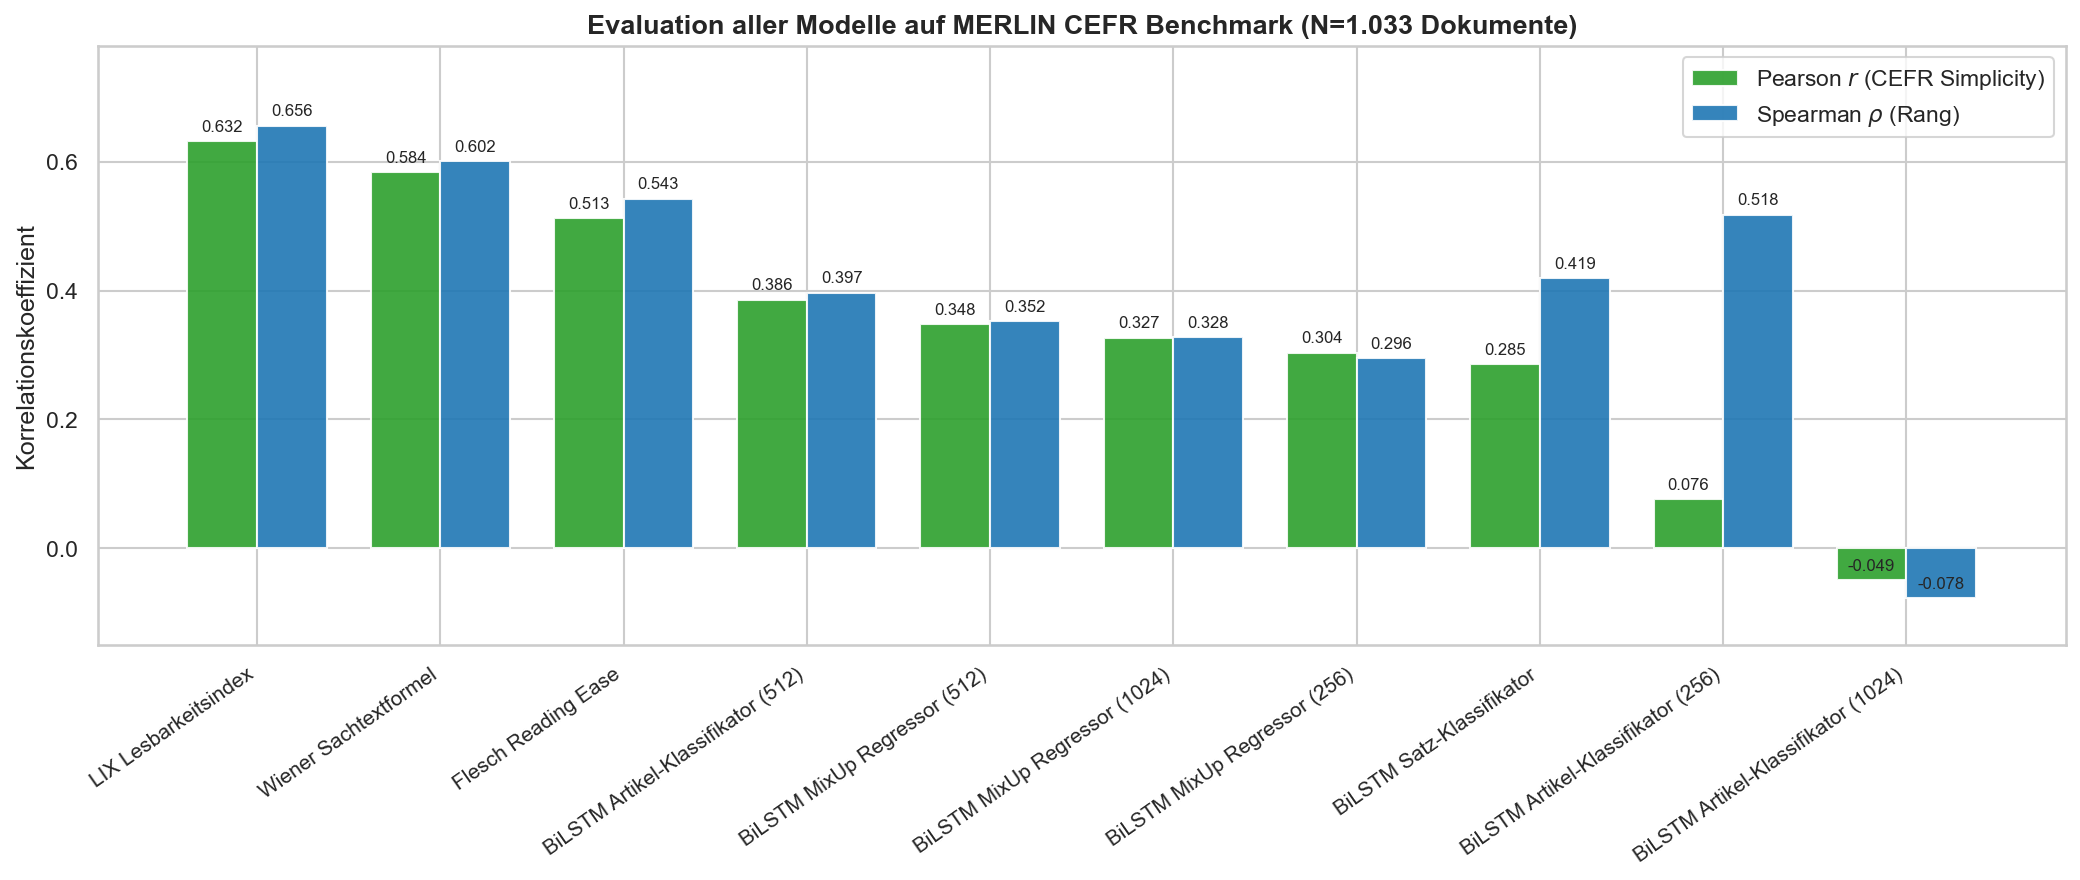

In [4]:
# 1. Plot: Barchart der Korrelationen
plt.figure(figsize=(14, 6))
df_plot = df_summary_merlin.sort_values(by="Pearson r (Simplicity)", ascending=False)

x = np.arange(len(df_plot))
width = 0.38

plt.bar(x - width/2, df_plot["Pearson r (Simplicity)"], width, label="Pearson $r$ (CEFR Simplicity)", color="#2ca02c", alpha=0.9)
plt.bar(x + width/2, df_plot["Spearman ρ (Rang)"], width, label="Spearman $\\rho$ (Rang)", color="#1f77b4", alpha=0.9)

plt.xticks(x, df_plot["Modell"], rotation=35, ha="right", fontweight="medium", fontsize=10)
plt.ylabel("Korrelationskoeffizient")
plt.title("Evaluation aller Modelle auf MERLIN CEFR Benchmark (N=1.033 Dokumente)", fontsize=13, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.ylim(-0.15, 0.78)
for i in range(len(df_plot)):
    plt.text(i - width/2, df_plot["Pearson r (Simplicity)"].iloc[i] + 0.015, f"{df_plot['Pearson r (Simplicity)'].iloc[i]:.3f}", ha="center", fontsize=8)
    plt.text(i + width/2, df_plot["Spearman ρ (Rang)"].iloc[i] + 0.015, f"{df_plot['Spearman ρ (Rang)'].iloc[i]:.3f}", ha="center", fontsize=8)

plt.tight_layout()
os.makedirs("results/plots/experiments/merlin", exist_ok=True)
plt.savefig("results/plots/experiments/merlin/merlin_correlation_barchart.png", dpi=300)
plt.show()


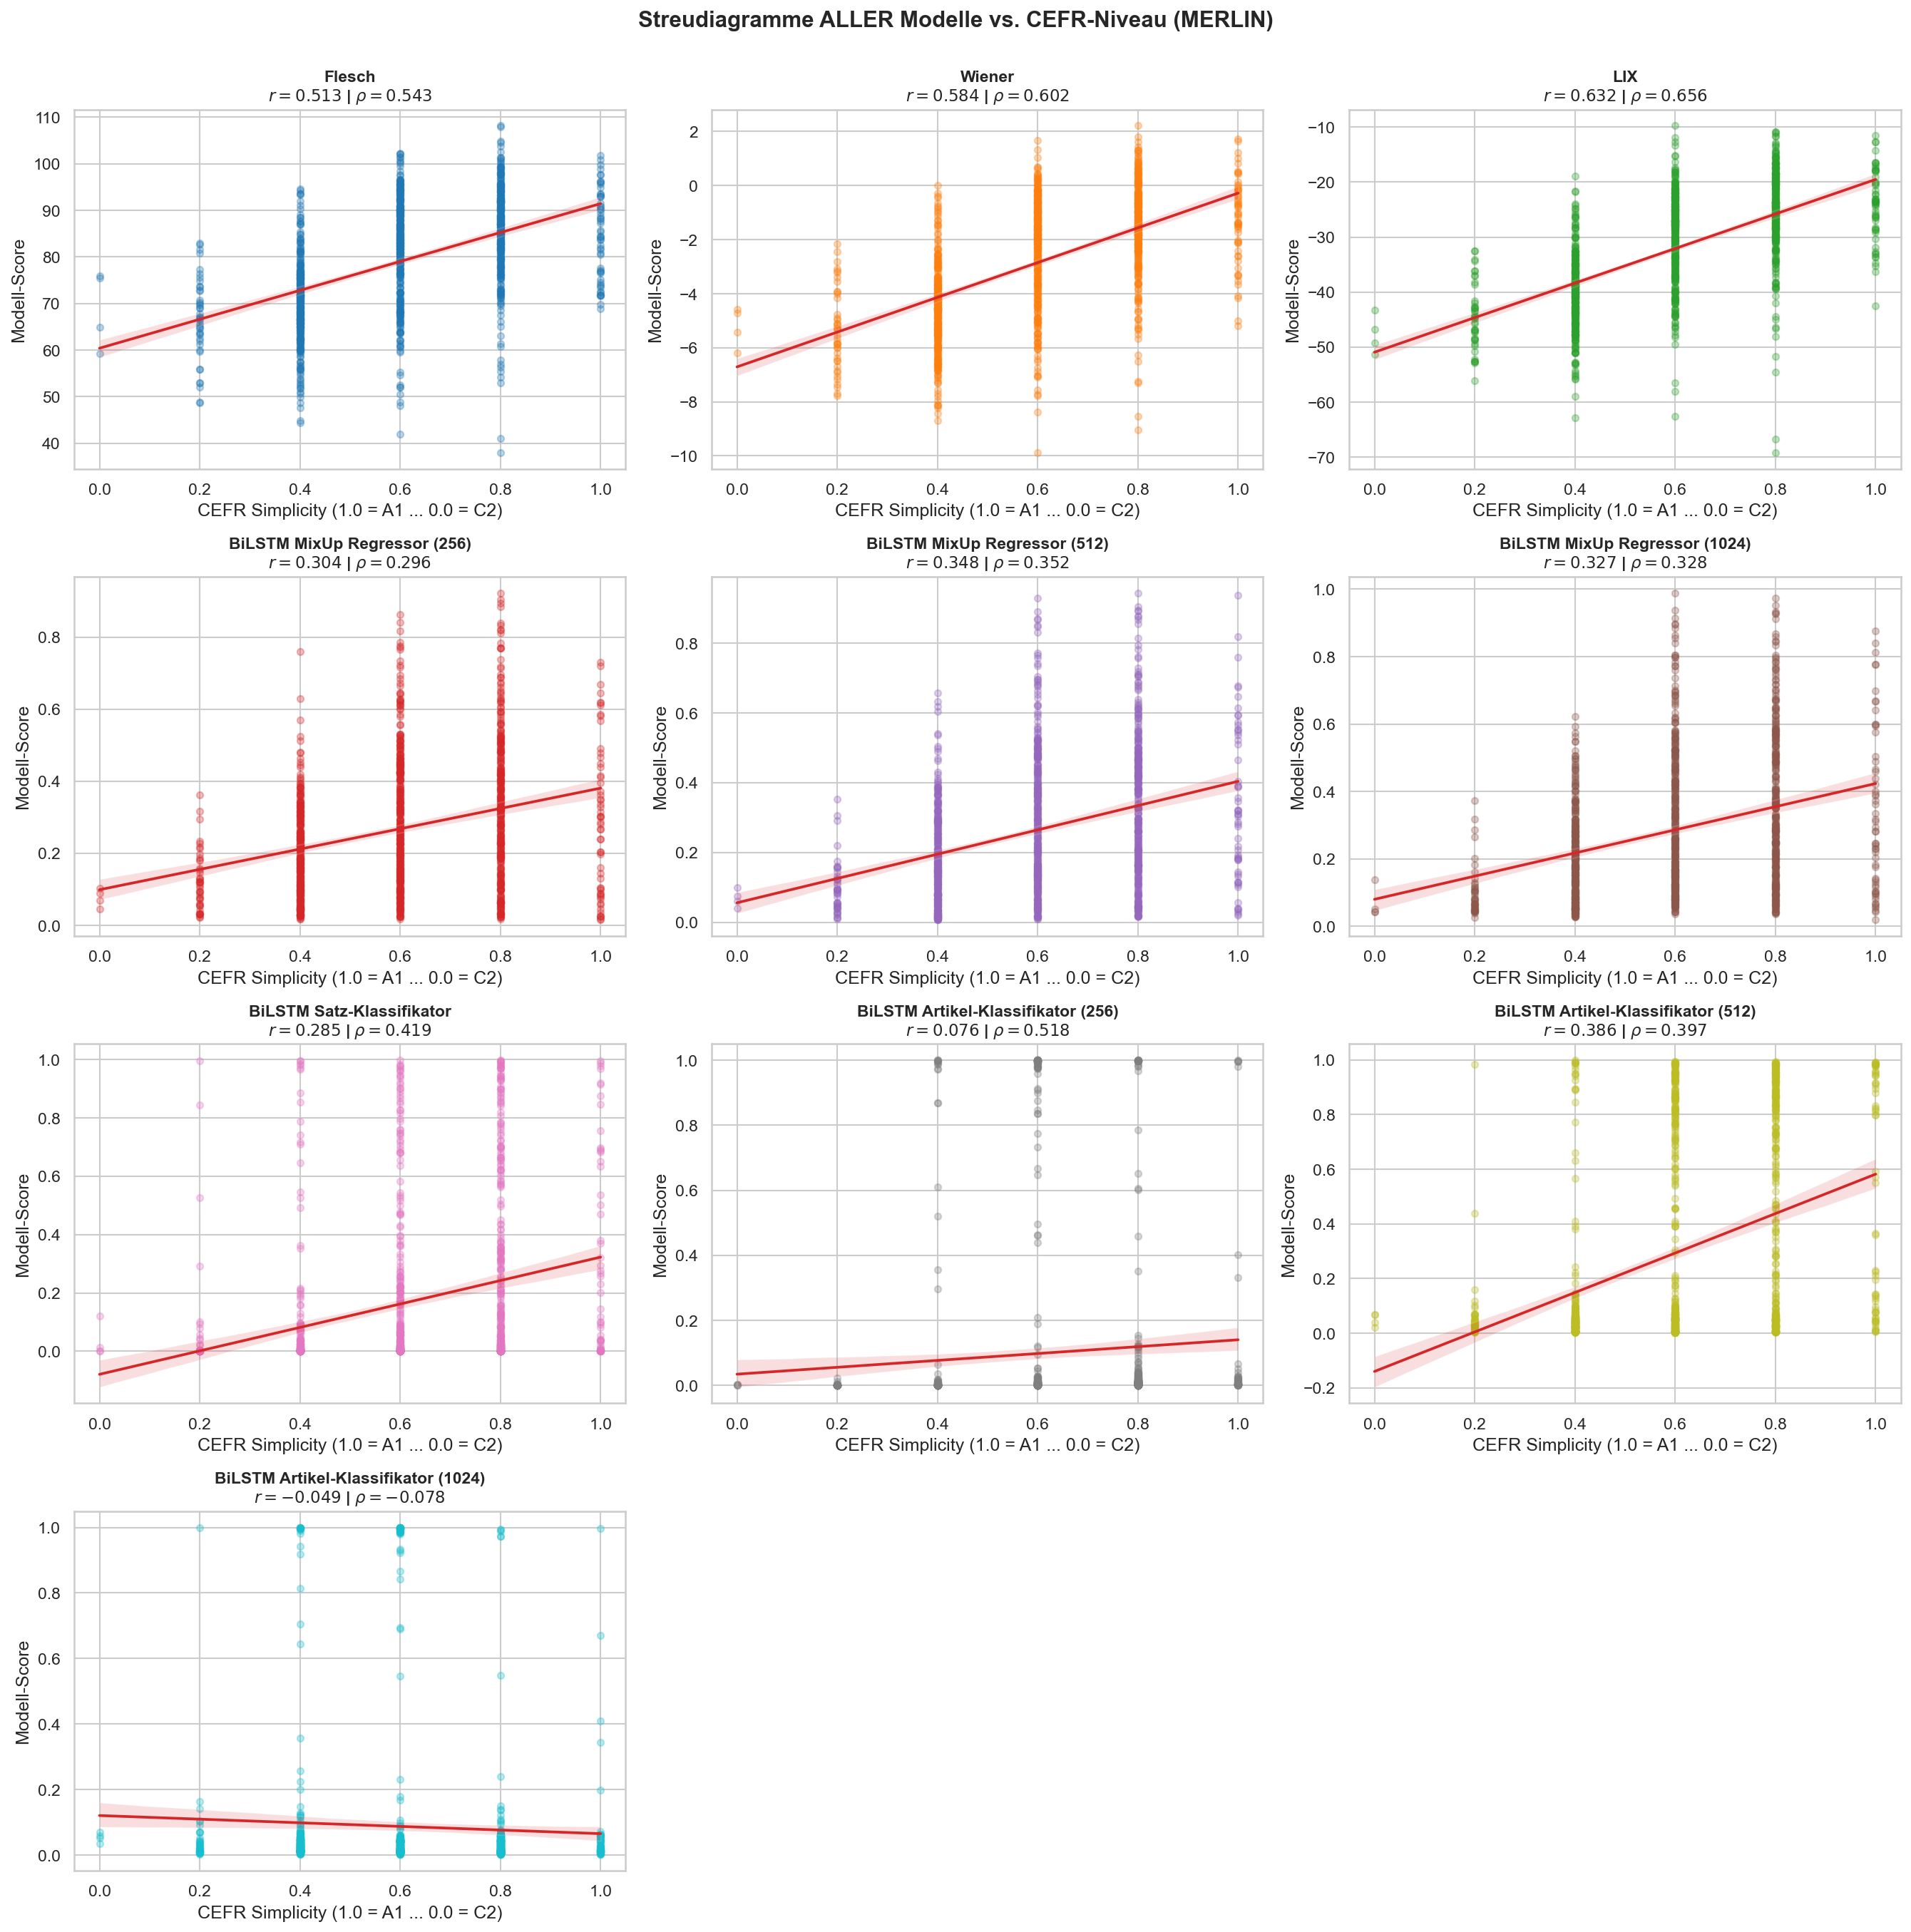

In [5]:
# 2. Plot: Streudiagramm-Grid für ALLE Modelle vs. CEFR Simplicity
pred_cols = [c for c in df_merlin.columns if c.startswith("Pred_")]
if pred_cols:
    n_models = len(pred_cols)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes = axes.flatten()
    colors = sns.color_palette("tab10", n_models)

    for i, col in enumerate(pred_cols):
        m_label = col.replace("Pred_", "").replace("_", " ")
        r_val, _ = pearsonr(df_merlin[col], df_merlin["cefr_simplicity"])
        rho_val, _ = spearmanr(df_merlin[col], df_merlin["cefr_simplicity"])

        sns.regplot(
            x=df_merlin["cefr_simplicity"], y=df_merlin[col], ax=axes[i],
            color=colors[i % len(colors)],
            scatter_kws={"alpha": 0.3, "s": 20},
            line_kws={"color": "#d62728", "lw": 1.8}
        )
        axes[i].set_title(f"{m_label}\n$r = {r_val:.3f}$ | $\\rho = {rho_val:.3f}$", fontsize=11, fontweight="bold")
        axes[i].set_xlabel("CEFR Simplicity (1.0 = A1 ... 0.0 = C2)")
        axes[i].set_ylabel("Modell-Score")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Streudiagramme ALLER Modelle vs. CEFR-Niveau (MERLIN)", fontsize=15, fontweight="bold", y=1.002)
    plt.tight_layout()
    plt.savefig("results/plots/experiments/merlin/merlin_scatter_all_models_grid.png", dpi=300)
    plt.show()


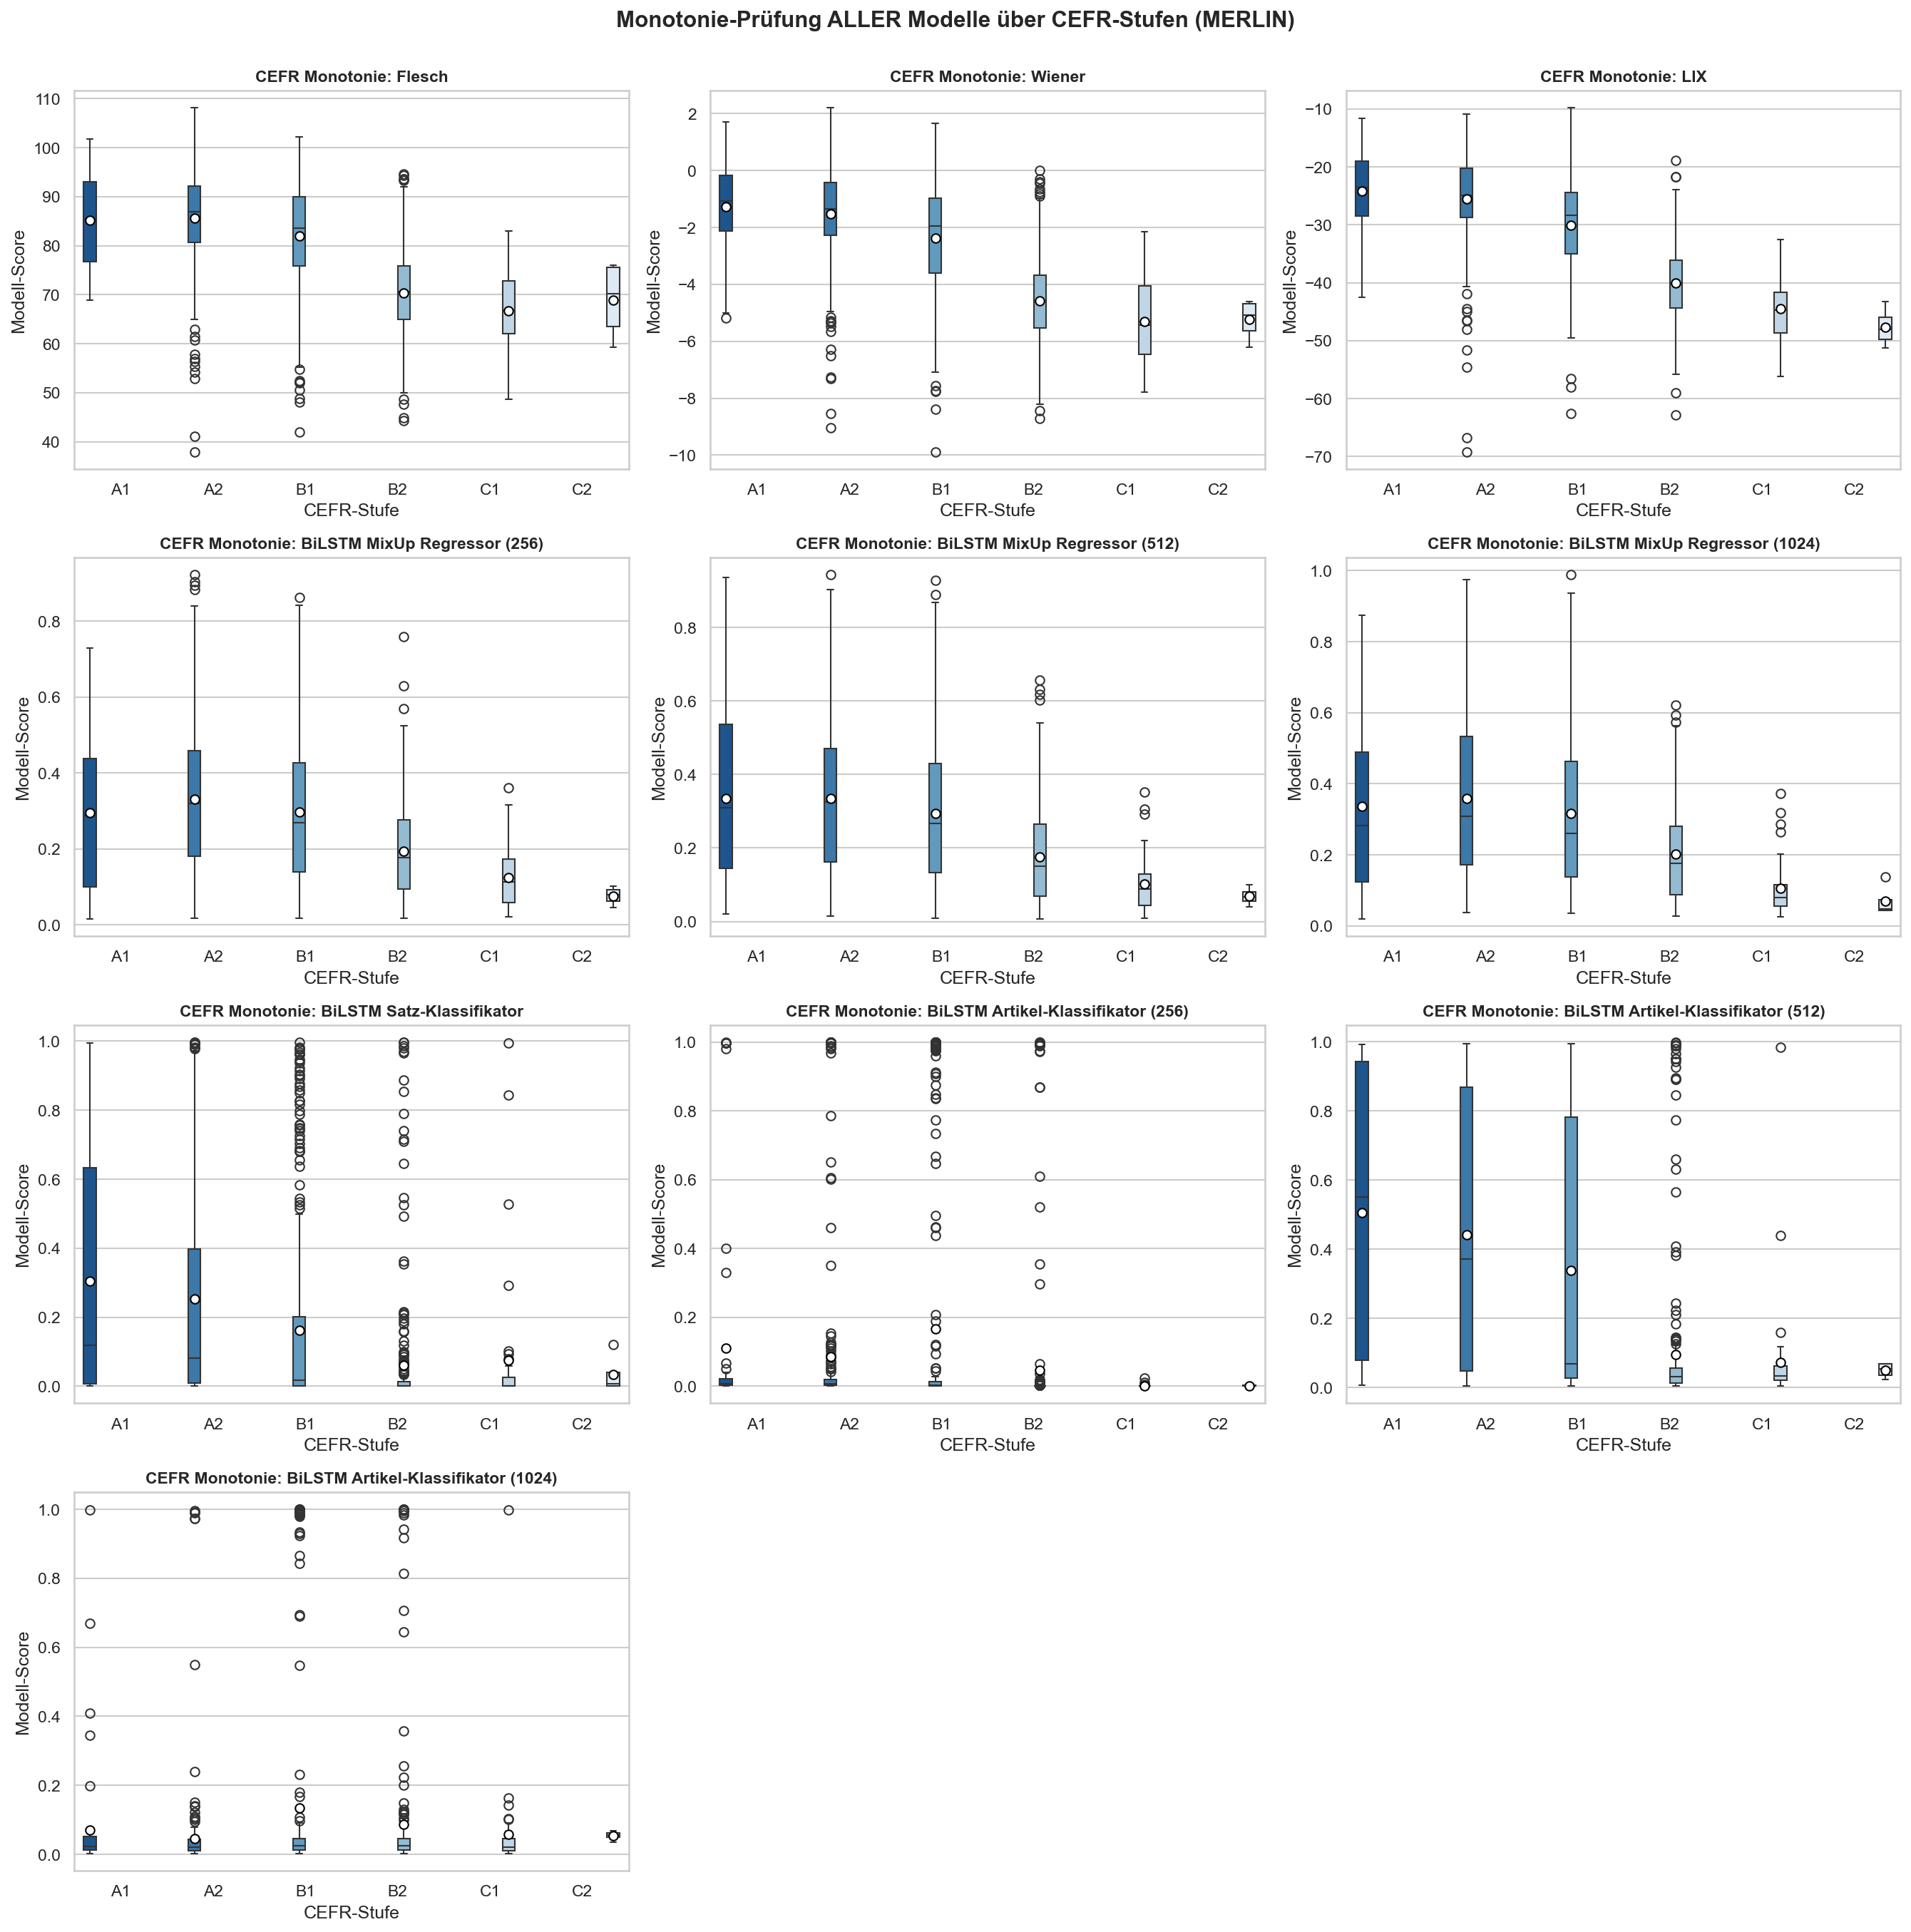

In [6]:
# 3. Plot: Monotonie-Boxplots über die CEFR-Stufen (A1, A2, B1, B2, C1)
cefr_levels = ["A1", "A2", "B1", "B2", "C1", "C2"]
valid_levels = [lvl for lvl in cefr_levels if lvl in df_merlin["cefr_level"].unique()]
df_merlin["CEFR_Category"] = pd.Categorical(df_merlin["cefr_level"], categories=valid_levels, ordered=True)

if pred_cols:
    fig_box, axes_box = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes_box = axes_box.flatten()

    for i, col in enumerate(pred_cols):
        m_label = col.replace("Pred_", "").replace("_", " ")
        sns.boxplot(
            data=df_merlin, x="CEFR_Category", y=col, ax=axes_box[i],
            palette="Blues_r", hue="CEFR_Category", legend=False, showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "6"}
        )
        axes_box[i].set_title(f"CEFR Monotonie: {m_label}", fontsize=11, fontweight="bold")
        axes_box[i].set_xlabel("CEFR-Stufe")
        axes_box[i].set_ylabel("Modell-Score")

    for j in range(i + 1, len(axes_box)):
        fig_box.delaxes(axes_box[j])

    plt.suptitle("Monotonie-Prüfung ALLER Modelle über CEFR-Stufen (MERLIN)", fontsize=15, fontweight="bold", y=1.002)
    plt.tight_layout()
    plt.savefig("results/plots/experiments/merlin/merlin_boxplots_all_models_grid.png", dpi=300)
    plt.show()


## 4. CEFR-Stufen Monotonie-Tabelle

Mittelwerte der Modell-Scores pro CEFR-Stufe zur quantitativen Überprüfung der Abstufungsgenauigkeit.

In [7]:
df_means = df_merlin.groupby("cefr_level", observed=False)[pred_cols].mean().reindex(["A1", "A2", "B1", "B2", "C1", "C2"]).dropna(how="all")
df_means.columns = [c.replace("Pred_", "").replace("_", " ") for c in df_means.columns]
display(df_means.round(4))


,Flesch,Wiener,LIX,BiLSTM MixUp Regressor (256),BiLSTM MixUp Regressor (512),BiLSTM MixUp Regressor (1024),BiLSTM Satz-Klassifikator,BiLSTM Artikel-Klassifikator (256),BiLSTM Artikel-Klassifikator (512),BiLSTM Artikel-Klassifikator (1024)
cefr_level,,,,,,,,,,
A1,85.1117,-1.2803,-24.1581,0.2957,0.3353,0.3368,0.3043,0.1097,0.5042,0.0707
A2,85.5594,-1.5182,-25.5472,0.3302,0.3356,0.3596,0.2537,0.0861,0.4419,0.0457
B1,81.9126,-2.3767,-30.0626,0.2966,0.2946,0.3166,0.1624,0.1670,0.3385,0.1339
B2,70.2973,-4.5699,-40.0966,0.1944,0.1762,0.2017,0.0607,0.0473,0.0955,0.0857
C1,66.7200,-5.3041,-44.4346,0.1241,0.1011,0.1055,0.0751,0.0014,0.0730,0.0588
C2,68.8861,-5.2359,-47.6577,0.0762,0.0686,0.0692,0.0334,0.0015,0.0499,0.0542


## 5. Detail- & Ausreißeranalyse

Analyse der Dokumente mit der größten Abweichung zwischen Modell-Vorhersage und menschlicher CEFR-Einstufung.

In [8]:
target_col = "Pred_BiLSTM_MixUp_Regressor_(1024)" if "Pred_BiLSTM_MixUp_Regressor_(1024)" in df_merlin.columns else (pred_cols[0] if pred_cols else None)

if target_col and target_col in df_merlin.columns:
    df_merlin["Diff"] = df_merlin["cefr_simplicity"] - df_merlin[target_col]
    
    print(f"=== Top 3 Dokumente: CEFR urteilt EINFACH (A1/A2), Modell ({target_col}) urteilt SCHWER ===")
    top_under = df_merlin.sort_values(by="Diff", ascending=False).head(3)
    for _, r in top_under.iterrows():
        print(f"• CEFR: {r['cefr_level']} | Modell Score: {r[target_col]:.4f} | Länge: {r['word_count']} Wörter")
        print(f"  Textauszug: {r['text'][:250]}...")
        print()

    print(f"=== Top 3 Dokumente: CEFR urteilt SCHWER (B2/C1), Modell ({target_col}) urteilt EINFACH ===")
    top_over = df_merlin.sort_values(by="Diff", ascending=True).head(3)
    for _, r in top_over.iterrows():
        print(f"• CEFR: {r['cefr_level']} | Modell Score: {r[target_col]:.4f} | Länge: {r['word_count']} Wörter")
        print(f"  Textauszug: {r['text'][:250]}...")
        print()


=== Top 3 Dokumente: CEFR urteilt EINFACH (A1/A2), Modell (Pred_BiLSTM_MixUp_Regressor_(1024)) urteilt SCHWER ===
• CEFR: A1 | Modell Score: 0.0197 | Länge: 38 Wörter
  Textauszug: Stadt X, 04.01.2012
Sehr geehrte Damen und Herren,
Ich möchte eine wohnen und 3 Zimmer und Balkon und Garage
und Garten und fenster 
Ich möchte ein küch groß 
Ich habe Keller
 was kostet its 500 E
Viel Gresß...

• CEFR: A1 | Modell Score: 0.0432 | Länge: 33 Wörter
  Textauszug: Stadt X, 04.01.2012
Sehr geehrte Damen und Herren,
Ich suche eine Wonung, funf Zimmer 130 m², mit dem Balkon, mit dem Garage, Bis 1000,- warm.
Ich dante Ihnen im varaus
mit freundlichen Grüßen...

• CEFR: A1 | Modell Score: 0.0485 | Länge: 19 Wörter
  Textauszug: Liber Jens
Herzliche Glückwünsche zum Babys geburt. Ich wünschen fil Gluk und fill, will Gisundheit.
Söine Gruße daine froindin....

=== Top 3 Dokumente: CEFR urteilt SCHWER (B2/C1), Modell (Pred_BiLSTM_MixUp_Regressor_(1024)) urteilt EINFACH ===
• CEFR: B1 | Modell Score: 0.